## Hidden Markov Model

Markets exhibit periods with disticnt behaviour and characteristics, these patterns are commonly refered to as market regimes. Market regimes are not directly defined or observable, however identifying these persistent changes in market behaviour can be useful for investment and risk-management decisions. For example, characteristics of a "crisis" market regime could be characterized by extreme volatility, large  absolute returns and persistant negative trends. Identifying such regimes could provide additional information about the current level of market risk.

Market regimes can be described as latent states that can't be observed directly. A Hidden Markov Model (HMM) provides a probabilistic framework that can be used to find hidden states through observable market data. The implied regimes depend strongly on the information provided to the model. The initial specification in this notebook uses three features: daily log returns, momentum, and conditional volatility estimated by the GARCH(1,1) model. 

The objective of this notebook is to evaluate whether the implemented HMM can identify persistent and economically interpretable market regimes, and then investigate how the model specification affects the resulting regime classification.

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t, norm
import statsmodels.api as smapi
import statsmodels as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

project_root = Path.cwd().parent


if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    

In [20]:
from src import data_loader as dl
from src import preprocessing as pp
from src import garch
from src import features
from src.markov_model.hmm import HiddenMarkovModel as hmm

# Download S&P 500 data from 2000-01-01 and compute daily log returns.
raw_data = dl.load_market_data()
market_data = pp.preprocess_market_data(raw_data)
garch_output = garch.fit_garch(market_data["Return"]*100)

hmm_features = features.build_hmm_features(market_data, garch_output)
split_idx = int(len(hmm_features) * 0.70)

train_df = hmm_features.iloc[:split_idx]
test_df = hmm_features.iloc[split_idx:]

X_train = train_df.to_numpy()
X_test = test_df.to_numpy()

In [21]:
HMM = hmm(feature_matrix = X_train, states = 3, covariance_type = "full").fit()

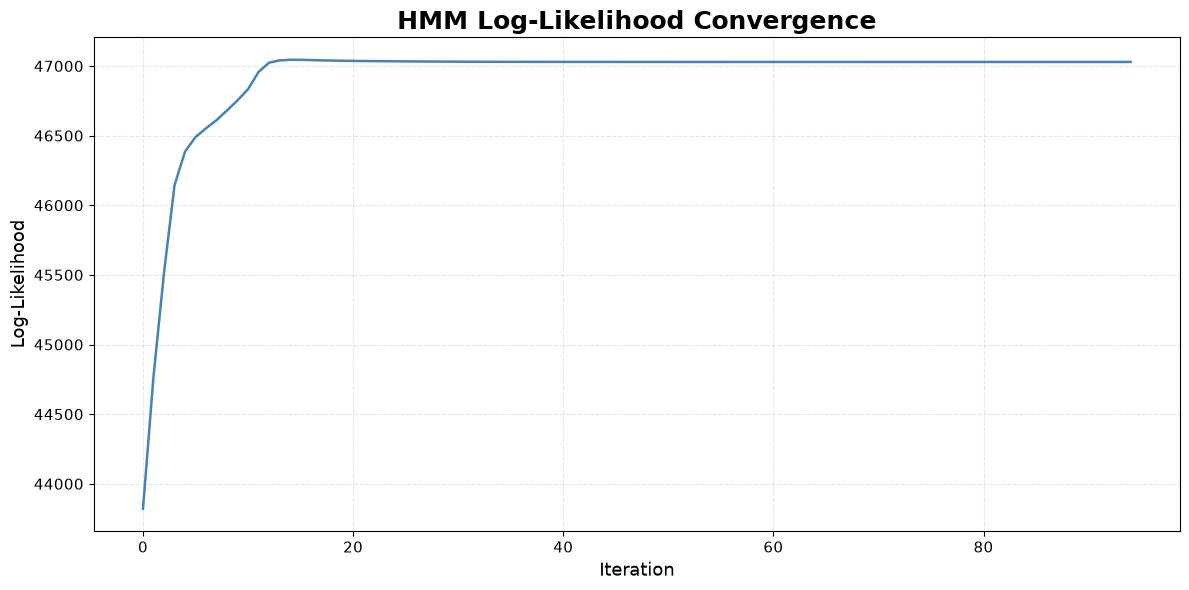

Iterations: 95
Final LL: 47029.11627959221

Last 10 improvements:
-0.0000430876
-0.0000362738
-0.0000305035
-0.0000256177
-0.0000214811
-0.0000179785
-0.0000150139
-0.0000125045
-0.0000103805
-0.0000085836
Number of decreases: 80
Largest decrease: -1.9216434113186551


In [31]:
plt.figure(figsize=(12, 6))

plt.plot(
    HMM.log_likelihood_history,
    linewidth=1.8,
    color="steelblue"
)

plt.title(
    "HMM Log-Likelihood Convergence",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Iteration", fontsize=13)
plt.ylabel("Log-Likelihood", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.3)
plt.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.show()

print("Iterations:", len(HMM.log_likelihood_history))
print("Final LL:", HMM.log_likelihood_history[-1])

print("\nLast 10 improvements:")

history = np.array(HMM.log_likelihood_history)

for diff in np.diff(history)[-10:]:
    print(f"{diff:.10f}")

diffs = np.diff(HMM.log_likelihood_history)

print("Number of decreases:", np.sum(diffs < 0))
print("Largest decrease:", np.min(diffs))